<a href="https://colab.research.google.com/github/CBravoR/AdvancedAnalyticsLabs/blob/master/notebooks/python/Lab_Prompt_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prompt engineering with Gemma 4 (E2B, instruction-tuned)

In this lab we explore prompt engineering for large language models (LLMs) using [Gemma 4 E2B-it](https://huggingface.co/google/gemma-4-E2B-it), Google's open-weight model in the "effective 2 billion parameters" size (5.1 billion in total, 2.3 billion active per token). The `-it` suffix means the model is instruction-tuned: it was trained to follow instructions and hold a conversation, which is what we need. It accepts text, images and audio; we use text only.

The model is released under the Apache 2.0 licence which means it can be used freely for both commercial and non-commercial purposes. It runs in bfloat16 on the free Colab GPU (T4 or better). Select a GPU runtime before you start (Runtime → Change runtime type).

We will start by installing and importing the required libraries. Gemma 4 needs a recent version of `transformers`, so the install upgrades it.

In [23]:
%pip install -U transformers accelerate
%pip install -U shap

In [2]:
# Imports
import os
import numpy as np
import pandas as pd

# Longer download timeout: the model weights are about 10 GB
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "300"

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Plots
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# PyTorch and Hugging Face
import torch
from transformers import AutoProcessor, AutoModelForMultimodalLM, set_seed

# XGBoost and SHAP
from xgboost import XGBClassifier
import shap

# Markdown output
from IPython.display import Markdown, display

## Basic prompt engineering

Gemma 4 is a multimodal model, so Hugging Face exposes it through a **processor** (which handles text, images and audio and holds the chat template) and a multimodal model class. We only feed it text, and the calls are the same as for a text-only model.

Downloading the weights takes a few minutes the first time. `device_map="auto"` places the model on the GPU, and `dtype="auto"` picks the precision the model was published in (bfloat16).

In [3]:
model_id = "google/gemma-4-E2B-it"

processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForMultimodalLM.from_pretrained(model_id, dtype="auto", device_map="auto")
model.eval()
print(f"Loaded {model_id} on {model.device} in {model.dtype}")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


processor_config.json:   0%|          | 0.00/1.69k [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/18.6k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.95k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.08k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 10.2GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/1951 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

Loaded google/gemma-4-E2B-it on cuda:0 in torch.bfloat16


The following code displays the **chat template** of Gemma 4. A chat template is the recipe that turns a list of messages (with roles such as `system`, `user` and `assistant`) into the single string of tokens the model actually reads. Look for the markers that open and close each turn, and for the place where the system message goes: the model never sees "roles", only this string.

If a model has no chat template, prompts must be formatted by hand. Gemma 4 has one, and it supports a system role natively.

In [4]:
print(processor.chat_template[:2000])   # the template is long; the first part shows the structure

{#
  Template: Google Gemma 4 Canonical Chat Template
  Author: Google Gemma Engineering Team
  Published: 2026-07-09
  Context: Fixed tool-calling loops, turn closures, and thinking content-ordering.
#}
{%- macro format_parameters(properties, required, filter_keys=false) -%}
    {%- set standard_keys = ['description', 'type', 'properties', 'required', 'nullable'] -%}
    {%- set ns = namespace(found_first=false) -%}
    {%- for key, value in properties | dictsort -%}
        {%- set add_comma = false -%}
        {%- if not filter_keys or key not in standard_keys -%}
            {%- if ns.found_first %},{% endif -%}
            {%- set ns.found_first = true -%}
            {{ key }}:{
            {%- if value['description'] -%}
                description:<|"|>{{ value['description'] }}<|"|>
                {%- set add_comma = true -%}
            {%- endif -%}
            {%- if value['type'] | upper == 'STRING' -%}
                {%- if value['enum'] -%}
                    {%- if a

We wrap generation in one helper so that every experiment below changes only the messages and the decoding parameters. The helper applies the chat template, generates, and decodes **only the new tokens**, so the answer comes back without the prompt.

Gemma 4 can produce a hidden "thinking" section before the answer. The helper strips it if it appears, so that what you read is the reply.

In [5]:
def generate(messages, max_new_tokens=512, temperature=0.2, top_p=0.8, repetition_penalty=1.5, seed=42):
    """Generate a reply to a list of chat messages and return only the new text."""
    set_seed(seed)
    inputs = processor.apply_chat_template(
        messages, tokenize=True, return_dict=True, return_tensors="pt", add_generation_prompt=True
    ).to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=temperature > 0,
            temperature=temperature if temperature > 0 else None,
            top_p=top_p,
            repetition_penalty=repetition_penalty,
        )
    new_tokens = out[0, inputs["input_ids"].shape[-1]:]
    text = processor.decode(new_tokens, skip_special_tokens=True)
    # If a thinking channel is present, keep only what follows it.
    if "<channel|>" in text:
        text = text.split("<channel|>")[-1]
    return text.strip()

A prompt is a list of messages. The **system message** sets the model's behaviour (who it is, how it answers); the **user message** is the question. We keep them apart because the system message is the part we will engineer.

In [6]:
system_message = "You are an expert assistant specializing in Banking Analytics and Business Analytics. Provide structured and factual responses."
user_prompt = "Explain the key differences between Banking Analytics and Business Analytics"

messages = [
    {"role": "system", "content": system_message},
    {"role": "user", "content": user_prompt},
]
messages

[{'role': 'system',
  'content': 'You are an expert assistant specializing in Banking Analytics and Business Analytics. Provide structured and factual responses.'},
 {'role': 'user',
  'content': 'Explain the key differences between Banking Analytics and Business Analytics'}]

The decoding parameters decide how the next token is chosen from the model's probabilities:

* `max_new_tokens=512` limits the length of the answer.
* `do_sample=True` samples instead of always taking the most likely token.
* `top_p=0.8` (nucleus sampling) restricts sampling to the smallest set of tokens whose probabilities add up to 80%.
* `temperature=0.2` flattens or sharpens the distribution: low values (0.2) give focused, repeatable answers; high values (1.0) give varied, creative ones.
* `repetition_penalty=1.5` discourages repeating the same phrases.

The model card recommends `temperature=1.0`, `top_p=0.95` and `top_k=64` for general chat. A risk analyst wants the opposite: low temperature and a narrow nucleus, so that the same question gives the same answer. We fix the seed for the same reason.

In [7]:
answer = generate(messages, max_new_tokens=512, temperature=0.2, top_p=0.8, repetition_penalty=1.5)
print(answer)

As an expert assistant specializing in Banking Analytics and Business Analytics, I can provide a clear, structured comparison of the key differences between these two fields.

While both disciplines utilize data to drive better decision-making, their **focus areas**, **data sources**, **analytical techniques**, and ultimate **business objectives** differ significantly due to the unique regulatory environment and core functions within the financial sector versus broader organizational management.

---

## Key Differences: Banking Analytics vs. Business Analytics

| Feature | Banking Analytics (Financial/Risk Focus) | Business Analytics (General Management Focus) |
| :--- | :--- | :--- |
| **Primary Objective** | Mitigating risk (credit, market), optimizing capital allocation, ensuring compliance, fraud detection, maximizing profitability on specific products. | Improving operational efficiency, enhancing customer experience (CX), driving sales growth, supply chain optimization, strategi

It works. The answer is Markdown, so we can render it instead of printing it.

In [8]:
display(Markdown(answer))

As an expert assistant specializing in Banking Analytics and Business Analytics, I can provide a clear, structured comparison of the key differences between these two fields.

While both disciplines utilize data to drive better decision-making, their **focus areas**, **data sources**, **analytical techniques**, and ultimate **business objectives** differ significantly due to the unique regulatory environment and core functions within the financial sector versus broader organizational management.

---

## Key Differences: Banking Analytics vs. Business Analytics

| Feature | Banking Analytics (Financial/Risk Focus) | Business Analytics (General Management Focus) |
| :--- | :--- | :--- |
| **Primary Objective** | Mitigating risk (credit, market), optimizing capital allocation, ensuring compliance, fraud detection, maximizing profitability on specific products. | Improving operational efficiency, enhancing customer experience (CX), driving sales growth, supply chain optimization, strategic planning across all departments. |
| **Core Data Sources** | Highly regulated internal transactional data ($\text{KYC}$, $\text{AML}$ records, loan portfolios, trading volumes, counterparty exposures). External macro-economic indicators. | Diverse datasets including CRM data, web traffic logs, ERP systems, marketing campaign performance metrics, HR data. |
| **Key Analytical Techniques** | Statistical modeling for credit scoring (e.g., Logistic Regression, Machine Learning classification models like Random Forests or Gradient Boosting), Time Series Analysis for forecasting interest rates, Stress Testing simulations. | Descriptive analytics (KPI dashboards), Predictive modeling for churn prediction, Segmentation analysis (Clustering algorithms - K-Means), A/B testing results interpretation. |
| **Regulatory Environment Impact** | Extremely high impact; analyses must adhere strictly to regulations ($\text{Basel III}$, $\text{CCAR}$) regarding model validation, fairness, transparency, and auditability. | Moderate impact; focus is generally on business strategy rather than direct systemic regulation enforcement. Compliance often follows general corporate governance rules. |
| **Typical Deliverables** | Credit Risk Scores, Liquidity Ratios forecasts, Fraud Alerts, Regulatory Reporting Packages, Portfolio Optimization strategies. | Customer Lifetime Value $(\text{CLV})$ reports, Sales Funnel visualizations, Operational Efficiency benchmarks, Marketing ROI assessments. |
| **Domain Expertise Required** | Deep knowledge of finance theory, economic principles, lending practices, derivatives markets, and complex statistical rigor required by regulators. | Strong understanding of process mapping, consumer behavior psychology, digital transformation trends, and cross-functional collaboration skills. |
| **Time Horizon** | Often focused on short

The response is well-written, but with prompt engineering, we can refine it further for improved structure and formatting.

Now, let's enhance it by providing more specific instructions for the response.

In [9]:
system_message = """STRICT INSTRUCTIONS:
1. First, provide a **clear definition** of the topic.
2. Then, explain **at least two key differences** in a **structured manner**.
   - Each difference must be in a **separate paragraph**.
   - Use **clear and concise language**.
3. Include **only** necessary information and useful details that are in line with the requested explanation.
"""

user_prompt = "What is Banking Analytics, and how does it differ from general Business Analytics?"

messages = [
    {"role": "system", "content": system_message},
    {"role": "user", "content": user_prompt},
]

In [10]:
answer = generate(messages, max_new_tokens=512, temperature=0.2, top_p=0.8, repetition_penalty=1.5)
display(Markdown(answer))

## Definition of Banking Analytics

Banking Analytics is the application of data analysis techniques (such as statistical modeling, machine learning, and predictive analytics) specifically to financial data within the banking sector. Its primary goal is to derive actionable insights for improving business performance, managing risk, enhancing customer experience, detecting fraud, optimizing lending decisions, and ensuring regulatory compliance within financial institutions.

## Key Differences Between Banking Analytics and General Business Analytics

One fundamental difference lies in the *domain specificity* of the focus area. General Business Analytics applies analytical methods across any industry—retail, manufacturing, healthcare, etc.—to solve broad operational or strategic problems like sales forecasting or supply chain optimization. In contrast, Banking Analytics focuses exclusively on unique datasets inherent to finance, such as transaction histories, credit scores, market volatility indicators, loan portfolios, and customer deposit patterns. This specialization requires domain knowledge specific to financial products, regulations (like Basel Accords), and economic cycles which are not central concerns in other industries.

The second major distinction rests upon the nature and criticality of the outcomes sought. While general Business Analytics often aims at maximizing revenue growth or efficiency gains through broader metrics, Banking Analytics places an extremely high emphasis on mitigating quantifiable risks and adhering to strict governance frameworks. Therefore, its outputs prioritize tasks directly related to fiduciary responsibility, including accurate credit risk scoring, anti-money laundering (AML) detection systems, stress testing capital adequacy, and identifying systemic vulnerabilities before they impact solvency. These objectives carry significantly higher stakes than typical non-financial business goals.

The model's response is now more narrative and engaging, accurately following the instructions provided.

## Prompt engineering with prediction model

In this section, we will use prompt engineering to guide the LLM in explaining delinquency status predictions based on SHAP values.

Let's begin by downloading a dataset to proceed with our analysis.

In [11]:
!gdown --fuzzy 'https://drive.google.com/file/d/1nrhxfnAkI0bZRXJiWu_JVKusAD9iHBpK/view?usp=sharing'

Downloading...
From: https://drive.google.com/uc?id=1nrhxfnAkI0bZRXJiWu_JVKusAD9iHBpK
To: /content/loan_app.csv
100% 1.81M/1.81M [00:00<00:00, 130MB/s]


In [12]:
df = pd.read_csv('loan_app.csv')
df

,target,CREDIT_SCORE,FIRST_TIME_HOMEBUYER,NUMBER_OF_UNITS,OCCUPANCY_STATUS,CLTV,DTI_RATIO,ORIGINAL_UPB,PROPERTY_TYPE,ORIGINAL_LOAN_TERM,NUMBER_OF_BORROWERS,MI_PERCENTAGE
0,1,685,N,1,P,80,36,68000,SF,360,1,0
1,0,751,N,1,P,80,36,112000,SF,360,2,0
2,0,716,N,1,P,80,43,199000,SF,360,2,0
3,0,706,N,1,P,80,50,196000,PU,180,2,0
4,0,720,N,1,P,72,31,115000,SF,360,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
49995,0,676,N,1,P,80,37,583000,PU,360,4,0
49996,0,762,N,1,P,48,40,605000,SF,360,1,0
49997,0,688,N,1,P,71,27,212000,SF,360,2,0
49998,0,728,N,1,P,80,50,224000,SF,180,2,0


Next, we will prepare the dataset for training by applying feature encoding, scaling, and train-test splitting to ensure the model learns effectively from the data.

In [13]:
X = df.drop(columns=["target"])  # Features
y = df["target"]  # Target variable

# Convert Categorical Features to Numerical
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()
numerical_columns = X.select_dtypes(exclude=["object"]).columns.tolist()

# Apply One-Hot Encoding
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_encoded = encoder.fit_transform(X[categorical_columns])

# Convert Encoded Data to DataFrame
X_encoded_df = pd.DataFrame(X_encoded, columns=encoder.get_feature_names_out(categorical_columns))

# Drop original categorical columns and merge one-hot encoded features
X = X.drop(columns=categorical_columns)
X = pd.concat([X, X_encoded_df], axis=1)

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale Only Numerical Features (NOT one-hot encoded features)
scaler = StandardScaler()
X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])  # Use same scaler for test set

X_train

,CREDIT_SCORE,NUMBER_OF_UNITS,CLTV,DTI_RATIO,ORIGINAL_UPB,ORIGINAL_LOAN_TERM,NUMBER_OF_BORROWERS,MI_PERCENTAGE,FIRST_TIME_HOMEBUYER_N,FIRST_TIME_HOMEBUYER_Y,OCCUPANCY_STATUS_I,OCCUPANCY_STATUS_P,OCCUPANCY_STATUS_S,PROPERTY_TYPE_CO,PROPERTY_TYPE_CP,PROPERTY_TYPE_MH,PROPERTY_TYPE_PU,PROPERTY_TYPE_SF
39087,0.191104,-0.128813,0.881354,-1.029810,0.735729,0.553156,-0.885513,0.666417,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
30893,0.142057,-0.128813,-1.835857,-1.377273,-1.006542,-1.912859,-0.885513,-0.472165,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
45278,0.223802,-0.128813,1.158620,0.290548,-0.584802,0.553156,-0.885513,1.899880,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
16398,-0.798013,-0.128813,-0.615885,-0.195900,-0.854439,0.553156,1.046656,-0.472165,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
13653,0.387293,-0.128813,-0.283165,0.707504,1.461675,0.553156,1.046656,-0.472165,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0.240151,-0.128813,0.604087,-1.377273,-1.082594,-1.912859,-0.885513,-0.472165,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
44732,-0.454683,-0.128813,0.604087,0.012578,-0.446527,0.553156,-0.885513,-0.472165,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
38158,0.395467,-0.128813,-2.279483,-1.307781,-0.405044,0.553156,-0.885513,-0.472165,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
860,-0.062306,-0.128813,0.604087,-0.682348,-0.557147,0.553156,1.046656,-0.472165,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


Now, we will train an XGBoost model to predict loan delinquency status.

In [25]:
negative_count = np.sum(y_train == 0)  # Count of class 0
positive_count = np.sum(y_train == 1)  # Count of class 1
scale_pos_weight = negative_count / positive_count  # Weight ratio

# Train XGBoost Classifier
xgb_model = XGBClassifier(max_depth=3,
                          learning_rate=0.01,
                          n_estimators=200,
                          verbosity=0,
                          objective='binary:logistic',
                          eval_metric="logloss",
                          booster='gbtree',
                          n_jobs=-1,
                          gamma=0.001,
                          subsample=0.632,
                          colsample_bytree=1,
                          colsample_bylevel=1,
                          colsample_bynode=1,
                          reg_alpha=0,
                          reg_lambda=0.1,
                          random_state=428,
                          tree_method="hist",
                          scale_pos_weight=scale_pos_weight,
                          # Recent XGBoost versions turn categorical support on by default. Our
                          # features are already one-hot encoded, and SHAP's TreeExplainer refuses
                          # models with the flag on, so we switch it off.
                          enable_categorical=False
                          )

xgb_model.fit(X_train, y_train)

# Make Predictions
y_pred = xgb_model.predict(X_test)

# Evaluate Model Performance
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6838
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.69      0.80      9159
           1       0.16      0.62      0.25       841

    accuracy                           0.68     10000
   macro avg       0.55      0.66      0.52     10000
weighted avg       0.89      0.68      0.75     10000



We analyzes feature importance in the XGBoost model using SHAP (SHapley Additive exPlanations) to explain why the model predicts a loan as delinquent or not.

The SHAP summary plot provides:
* Feature importance ranking (sorted by impact).
* How each feature affects predictions (positive/negative impact).
* Distribution of SHAP values for different feature values.

 98%|===================| 9751/10000 [00:26<00:00]        /tmp/ipykernel_772/2406430990.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


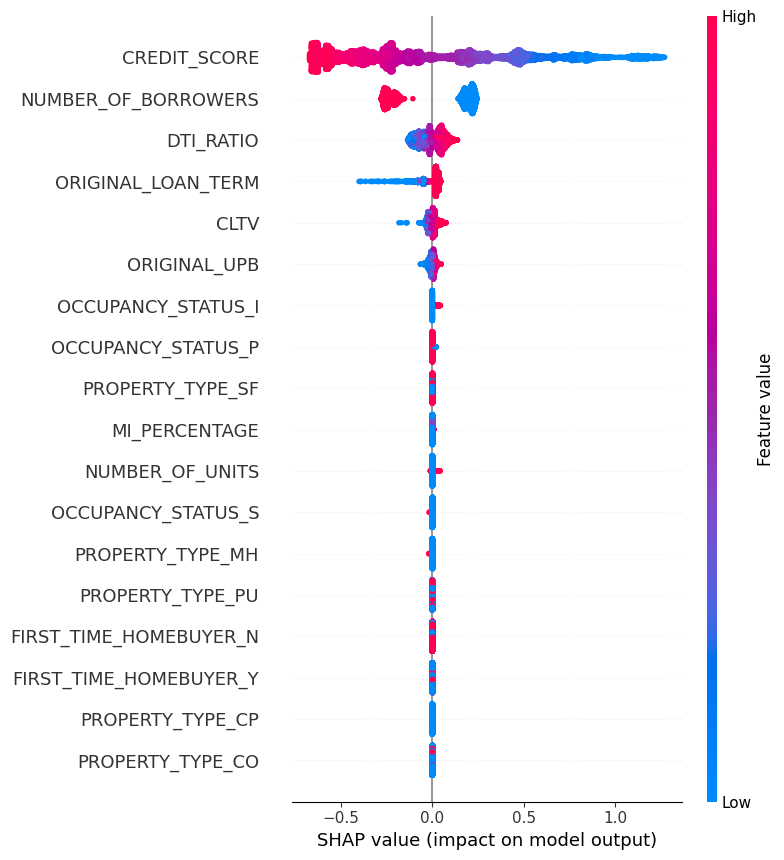

In [27]:
# Explain Model Predictions using SHAP
# The background sample is set on the masker, not on the explainer. TreeSHAP with a
# background ("interventional") runs in time proportional to (background rows) x (explained rows),
# so we explain the first 100 test cases. Explaining all 10,000 takes about 20x longer.
masker = shap.maskers.Independent(X_train, max_samples=100)
explainer = shap.Explainer(xgb_model, masker)
shap_values = explainer(X_test)  # SHAP values for the first 100 test cases

# Summarize SHAP Values
shap.summary_plot(shap_values, X_test)

We retrieve and format SHAP values for one test sample, making it easier to generate human-readable explanations using Gemma.

In [28]:
# Select an example loan case (e.g., first sample in test set)
sample_index = 10  # Change this index if needed
shap_values_sample = shap_values[sample_index].values
sample_features = X_test.iloc[sample_index]

# Convert SHAP values into dictionary format for input
shap_dict = {feature: shap_values_sample[i] for i, feature in enumerate(sample_features.index)}

# Target label for the selected sample
pred_label = y_pred[sample_index]

print("\nSHAP Values for Sample Client:\n", shap_dict)


SHAP Values for Sample Client:
 {'CREDIT_SCORE': np.float64(0.671641972932266), 'NUMBER_OF_UNITS': np.float64(-6.198739400133491e-05), 'CLTV': np.float64(-0.012548520302516408), 'DTI_RATIO': np.float64(0.013168096751905977), 'ORIGINAL_UPB': np.float64(0.004487428976863157), 'ORIGINAL_LOAN_TERM': np.float64(0.03454883362035616), 'NUMBER_OF_BORROWERS': np.float64(0.20632109559046513), 'MI_PERCENTAGE': np.float64(-4.907756170723587e-05), 'FIRST_TIME_HOMEBUYER_N': np.float64(0.0), 'FIRST_TIME_HOMEBUYER_Y': np.float64(0.0), 'OCCUPANCY_STATUS_I': np.float64(-0.0006197037303354591), 'OCCUPANCY_STATUS_P': np.float64(-0.0011978431325405836), 'OCCUPANCY_STATUS_S': np.float64(0.0), 'PROPERTY_TYPE_CO': np.float64(0.0), 'PROPERTY_TYPE_CP': np.float64(0.0), 'PROPERTY_TYPE_MH': np.float64(0.0), 'PROPERTY_TYPE_PU': np.float64(0.0), 'PROPERTY_TYPE_SF': np.float64(-0.00025783297722227873)}


Before proceeding to Gemma, let's generate a bar plot of SHAP values for the sampled loan to visualize which features have the most impact on the delinquency prediction.

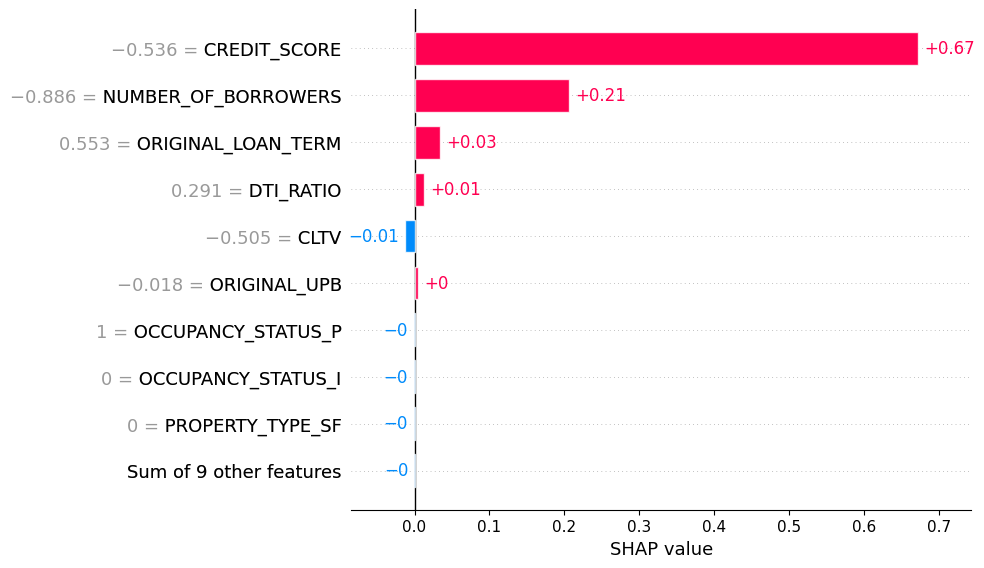

In [29]:
shap.plots.bar(shap_values[sample_index])

Finally, we format SHAP values into a structured prompt to enable Gemma to generate an interpretable explanation of why a loan is predicted as delinquent or not.

We first sort SHAP values by absolute magnitude, prioritizing the most impactful features. Then, we select the top 3 features to keep the explanation concise and focused.

In the prompt, we will:

* Ensure a structured format for clear and consistent Gemma responses.
* Eliminate unnecessary or unrelated information from the generated output.
* Clearly state the model's decision using SHAP-based reasoning.

In [ ]:
def format_shap_explanation(system_message, sample_features, shap_dict, pred_label, scaler):
    # Convert scaled numerical values back to original values
    original_values = scaler.inverse_transform(sample_features[numerical_columns].values.reshape(1, -1))
    original_feature_values = {feature: original_values[0][i] for i, feature in enumerate(numerical_columns)}

    # Sort SHAP values by absolute magnitude (most impactful features first)
    top_features = sorted(shap_dict.items(), key=lambda x: abs(x[1]), reverse=True)[:3]

    # Generate SHAP explanation text
    shap_text = "\n".join(
        [f"{feature}: SHAP value = {shap_value:.4f}, feature value = {original_feature_values[feature]:.2f}"
         for feature, shap_value in top_features]
    )

    print(shap_text)
    # Define loan delinquency status
    delinquency_status = "likely to be delinquent" if pred_label == 1 else "unlikely to be delinquent"
    print("predicted delinquency: ", delinquency_status)

    # Construct a revised prompt with explicit instructions and structured format
    user_prompt = f"""
The model predicts that the client is {delinquency_status}.

Here are the three most important features influencing the prediction:

{shap_text}

### Instructions:
- Analyze how each of three features contributes to the prediction.
- **Use correct feature names, not feature values.**
- **Strictly follow the structured response format.**
- **SHAP values must be interpreted correctly**:
  - **A positive SHAP value means the feature increases delinquency risk.**
  - **A negative SHAP value means the feature decreases delinquency risk.**

### Response Format:
- Feature Name: [Feature Name]
- Effect on Risk: [Explain whether a higher or lower value increases delinquency risk and why.]
- SHAP Impact: [Clearly state whether the SHAP value shows an increase or decrease in delinquency risk and explain its significance.]
- Reason: [Provide an individual reason for the source of risk.]

The output will be shown in Markdown format, so style your response accordingly.

### Example Response
**Feature Name: Credit Score**
- Effect on Risk: A higher credit score reduces delinquency risk because it indicates a strong repayment history and financial responsibility.
- SHAP Impact: The SHAP value **-0.5862** shows that **including credit score for this client decreases** the probability of delinquency, meaning the model considers this a strong indicator of financial reliability.
- Reason: A high credit score reflects a history of timely payments and responsible credit usage, which are key indicators of financial stability.

**Feature Name: Employment Length**
- Effect on Risk: A higher employment length reduces delinquency risk because it indicates job stability and a stable salary.
- SHAP Impact: The SHAP value **-0.723** shows that **including employment length for this client decreases** the probability of delinquency, meaning the model considers this a strong indicator of financial reliability. 
- Reason: A long employment length suggests consistent income and financial stability, which reduces the likelihood of delinquency.

Now begin your structured analysis:
"""


    messages = [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
    ]

    return messages

We also define instructions to guide the LLM in analyzing SHAP values for loan delinquency predictions.

In [43]:
system_message = """
You are a financial risk analyst. Your job is to analyze SHAP values and provide structured, fact-based explanations of the model's predictions.

Guidelines:
1. Interpret SHAP values correctly:
   - **A positive SHAP value means the feature increases delinquency risk.**
   - **A negative SHAP value means the feature decreases delinquency risk.**
2. **Do not contradict basic financial logic**:
   - A **higher credit score should always reduce risk** unless explicitly stated otherwise.
3. **Strictly follow the response format. Do not add extra text or repeat information.**
4. **Do not argue against the given ranking of features.**
5. **Avoid repetition, unnecessary details, or ranking errors.**
6. **Use clear and concise language.**
7. **Analyze the details of each variable and discuss its individual meaning.**
8. **Provide an unique reply for each variable depending on your beliefs on what may be the source of risk. The space for this will be tagged as _REASON_.
"""

messages = format_shap_explanation(system_message, sample_features, shap_dict, pred_label, scaler)

CREDIT_SCORE: SHAP value = 0.6716, feature value = 683.00
NUMBER_OF_BORROWERS: SHAP value = 0.2063, feature value = 1.00
ORIGINAL_LOAN_TERM: SHAP value = 0.0345, feature value = 360.00
predicted delinquency:  likely to be delinquent


Finally, let's give it a try!

In [44]:
answer = generate(messages, max_new_tokens=512, temperature=0.1, top_p=0.5, repetition_penalty=1.0)

In [45]:
display(Markdown(answer))

**Feature Name: CREDIT_SCORE**
- Effect on Risk: A higher credit score reduces delinquency risk because it indicates a strong repayment history and financial responsibility.
- SHAP Impact: The SHAP value of 0.6716 shows that **including the current credit score increases** the probability of delinquency, indicating that this specific score level is a significant risk factor for this client.
- Reason: _REASON_: A relatively lower credit score suggests potential past financial difficulties or higher inherent credit risk, making the client more susceptible to default.

**Feature Name: NUMBER_OF_BORROWERS**
- Effect on Risk: A higher number of borrowers increases delinquency risk because it suggests a higher overall debt burden or financial strain.
- SHAP Impact: The SHAP value of 0.2063 shows that **having a higher number of borrowers increases** the probability of delinquency, indicating that the existing debt load is a moderate driver of risk.
- Reason: _REASON_: _REASON_: A high number of existing obligations suggests the client may be overextended financially, increasing the likelihood of struggling to meet new payment obligations.

**Feature Name: ORIGINAL_LOAN_TERM**
- Effect on Risk: A longer original loan term can increase delinquency risk as it implies a longer period over which payments must be made, potentially increasing long-term exposure.
- SHAP Impact: The SHAP value of 0.0345 shows that **the original loan term has a negligible positive impact** on the probability of delinquency for this client.
- Reason: _REASON_: _REASON_: The length of the loan term is not a primary driver of risk in this instance, suggesting that other factors (like credit score or debt load) are more influential.

Pretty good, no? Of course, a better model will give more detailed and accurate answers. In future labs, we will fine-tune our models to achieve even better performance. Now you can create your own models!